In [ ]:
# =============================================================================
# ClinicalEarlyCancerDF
# Nested Cross-Validation Implementation
#
# Chapter 5
# PhD Thesis
# City University of Hong Kong
# =============================================================================

#Section 2 — Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd

from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import (
    OneHotEncoder,
    LabelEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import RFECV

from bayes_opt import BayesianOptimization

import joblib

# Section 3 — Configuration

Instead of hard coding everything

In [ ]:
DATASET_NAME = "CancerSEEK"

RANDOM_STATE = 42

OUTER_FOLDS = 10

INNER_FOLDS = 5

N_BAYES_ITER = 20

SCORING = "roc_auc"

RESULT_PATH = "outputs/"

FEATURE_PATH = "selected_features/"

REPORT_PATH = "reports/"

Later we can change

DATASET_NAME="DELFI"

and the whole notebook works.

That is exactly what a generalized framework should do.

# **Section 4 — Load Dataset**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ClinicalEarlyCancerDF/Data/CancerSEEK_Dataset_AVG.csv")

print("="*80)
print("ClinicalEarlyCancerDF")
print("="*80)

print(f"Dataset : {DATASET_NAME}")

print(f"Instances : {df.shape[0]}")

print(f"Features : {df.shape[1]-1}")

print("="*80)

ClinicalEarlyCancerDF
Dataset : CancerSEEK
Instances : 1818
Features : 46


# **Section 5 — Exploratory Analysis**

In [ ]:
print(df.info())

print()

print(df.head())

print()

print(df.describe())

print()

print(df["class"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1818 entries, 0 to 1817
Data columns (total 47 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   omega_score'                    1818 non-null   float64
 1   'Mutant allele frequency (\%)'  1818 non-null   float64
 2   ' Mutant fragments/mL plasma'   1818 non-null   float64
 3   'AFP (pg/ml)'                   1818 non-null   float64
 4   'Angiopoietin-2 (pg/ml)'        1818 non-null   float64
 5   'AXL (pg/ml)'                   1818 non-null   float64
 6   'CA-125 (U/ml)'                 1818 non-null   float64
 7   'CA 15-3 (U/ml)'                1818 non-null   float64
 8   'CA19-9 (U/ml)'                 1818 non-null   float64
 9   'CD44 (ng/ml)'                  1818 non-null   float64
 10  'CEA (pg/ml)'                   1818 non-null   float64
 11  'CYFRA 21-1 (pg/ml)'            1818 non-null   float64
 12  'DKK1 (ng/ml)'                  18

# Section 6 — Missing Value Detection

In [ ]:
missing = df.isnull().sum()

missing = missing[missing>0]

if len(missing)==0:

    print("✓ No missing values detected.")

    print("Skipping LightGBM Imputation.")

else:

    print("Missing values detected.")

    print(missing)

    print("Running LightGBM Imputation...")

✓ No missing values detected.
Skipping LightGBM Imputation.


# **Section 7 — Prepare Features**

In [ ]:
target = "class"

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

# Section 9 — Initialize Result Containers

In [ ]:
# =============================================================================
# Storage for Evaluation Results
# =============================================================================

outer_fold_results = []

selected_features_all_folds = []

best_params_all_folds = []

feature_frequency = Counter()

fold_predictions = []

fold_probabilities = []

fold_true_labels = []

# **Section 8 — Prepare Nested CV**

In [ ]:
outer_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# **bRFE**

In [ ]:
# =============================================================================
# Best Recursive Feature Elimination (bRFE)
# =============================================================================

import numpy as np
import pandas as pd

from copy import deepcopy
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# =============================================================================
# Configuration
# =============================================================================

TOLERANCE = 1e-3


# =============================================================================
# Helper Function:
# Evaluate one feature subset using Inner Cross Validation
# =============================================================================

def evaluate_subset(
        X,
        y,
        feature_idx,
        estimator,
        cv=5,
        random_state=42):

    """
    Evaluate one feature subset using Inner Stratified CV.

    Parameters
    ----------
    X : ndarray
    y : ndarray
    feature_idx : list
        Selected feature indices
    estimator : sklearn estimator
    cv : int

    Returns
    -------
    mean_auc
    mean_acc
    """

    inner_cv = StratifiedKFold(
        n_splits=cv,
        shuffle=True,
        random_state=random_state
    )

    auc_scores = []
    acc_scores = []

    for train_idx, valid_idx in inner_cv.split(X, y):

        X_train = X[train_idx][:, feature_idx]
        X_valid = X[valid_idx][:, feature_idx]

        y_train = y[train_idx]
        y_valid = y[valid_idx]

        model = clone(estimator)

        model.fit(X_train, y_train)

        prob = model.predict_proba(X_valid)[:, 1]
        pred = model.predict(X_valid)

        auc_scores.append(
            roc_auc_score(y_valid, prob)
        )

        acc_scores.append(
            accuracy_score(y_valid, pred)
        )

    return (
        np.mean(auc_scores),
        np.mean(acc_scores)
    )


# =============================================================================
# Main bRFE Function
# =============================================================================

def bRFE(
        X_train,
        y_train,
        feature_names=None,
        inner_cv=5,
        random_state=42):

    """
    Best Recursive Feature Elimination (bRFE)

    Two candidate learners

        1. XGBoost
        2. Random Forest

    Each learner recursively removes the least important
    feature until only two remain.

    The best subset is selected according to

        1. Maximum AUC
        2. Maximum Accuracy
        3. Minimum number of features

    Returns
    -------

    selected_feature_idx

    selected_feature_names

    best_model

    best_auc

    best_acc
    """

    if feature_names is None:

        feature_names = [
            f"Feature_{i}"
            for i in range(X_train.shape[1])
        ]

    learners = {

        "XGB": XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=random_state,
            verbosity=0
        ),

        "RF": RandomForestClassifier(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1
        )

    }

    overall_best_auc = -np.inf
    overall_best_acc = -np.inf
    overall_best_model = None
    overall_best_subset = None

    print("=" * 70)
    print("Best Recursive Feature Elimination (bRFE)")
    print("=" * 70)

    # =============================================================
    # Evaluate each learner
    # =============================================================

    for learner_name, learner in learners.items():

        print(f"\nEvaluating learner: {learner_name}")

        # Start with all features
        current_features = list(range(X_train.shape[1]))

        learner_best_auc = -np.inf
        learner_best_acc = -np.inf
        learner_best_subset = deepcopy(current_features)

        # -----------------------------------------------------
        # Recursive Elimination
        # -----------------------------------------------------

        while len(current_features) >= 2:

            current_X = X_train[:, current_features]

            # ---------------------------------------------
            # Evaluate current subset
            # ---------------------------------------------

            mean_auc, mean_acc = evaluate_subset(

                X=current_X,

                y=y_train,

                feature_idx=list(range(current_X.shape[1])),

                estimator=learner,

                cv=inner_cv,

                random_state=random_state

            )

            # ---------------------------------------------
            # Save Best Subset
            # Objective:
            #
            # 1. Maximum AUC
            # 2. Maximum Accuracy
            # 3. Minimum Features
            # ---------------------------------------------

            update = False

            if mean_auc > learner_best_auc + TOLERANCE:

                update = True

            elif abs(mean_auc - learner_best_auc) <= TOLERANCE:

                if mean_acc > learner_best_acc + TOLERANCE:

                    update = True

                elif abs(mean_acc - learner_best_acc) <= TOLERANCE:

                    if len(current_features) < len(learner_best_subset):

                        update = True

            if update:

                learner_best_auc = mean_auc
                learner_best_acc = mean_acc
                learner_best_subset = deepcopy(current_features)

            # ---------------------------------------------
            # Stop when only two features remain
            # ---------------------------------------------

            if len(current_features) == 2:

                break

            # ---------------------------------------------
            # Train learner on current subset
            # ---------------------------------------------

            model = clone(learner)

            model.fit(

                current_X,

                y_train

            )

            # ---------------------------------------------
            # Feature Importance
            # ---------------------------------------------

            importance = model.feature_importances_

            # Rank features
            sorted_idx = np.argsort(importance)

            # Remove least important feature
            remove_local_idx = sorted_idx[0]

            del current_features[remove_local_idx]

            print(
                f"Remaining Features: {len(current_features):2d} | "
                f"AUC={mean_auc:.4f} | "
                f"ACC={mean_acc:.4f}"
            )

        print("\n---------------------------------------")
        print(f"{learner_name} Best Subset")
        print("---------------------------------------")
        print("Features :", len(learner_best_subset))
        print("Best AUC :", round(learner_best_auc,4))
        print("Best ACC :", round(learner_best_acc,4))

            # ----------------------------------------------------
        # Compare with Overall Best Learner
        # ----------------------------------------------------

    update = False

    if learner_best_auc > overall_best_auc + TOLERANCE:

           update = True

    elif abs(learner_best_auc - overall_best_auc) <= TOLERANCE:

        if learner_best_acc > overall_best_acc + TOLERANCE:

                update = True

        elif abs(learner_best_acc - overall_best_acc) <= TOLERANCE:

            if (overall_best_subset is None or
                    len(learner_best_subset) < len(overall_best_subset)):

                    update = True

    if update:

            overall_best_auc = learner_best_auc
            overall_best_acc = learner_best_acc
            overall_best_model = learner_name
            overall_best_subset = deepcopy(learner_best_subset)


    selected_feature_names = [
          feature_names[i]
          for i in overall_best_subset
      ]

    print("\n" + "=" * 70)
    print("bRFE Completed")
    print("=" * 70)
    print(f"Selected Learner : {overall_best_model}")
    print(f"Selected Features: {len(overall_best_subset)}")
    print(f"Best AUC         : {overall_best_auc:.4f}")
    print(f"Best Accuracy    : {overall_best_acc:.4f}")
    print("=" * 70)

    return {

          "selected_idx": overall_best_subset,

          "selected_features": selected_feature_names,

          "learner": overall_best_model,

          "auc": overall_best_auc,

          "accuracy": overall_best_acc

    }


In [ ]:
result = bRFE(
    X_train_outer.values,
    y_train_outer,
    feature_names=all_feature_names
)

print("bRFE Result:")
print(result)

Best Recursive Feature Elimination (bRFE)

Evaluating learner: XGB
Remaining Features: 53 | AUC=0.9977 | ACC=0.9853
Remaining Features: 52 | AUC=0.9972 | ACC=0.9835
Remaining Features: 51 | AUC=0.9975 | ACC=0.9829
Remaining Features: 50 | AUC=0.9975 | ACC=0.9872
Remaining Features: 49 | AUC=0.9976 | ACC=0.9866
Remaining Features: 48 | AUC=0.9973 | ACC=0.9853
Remaining Features: 47 | AUC=0.9974 | ACC=0.9847
Remaining Features: 46 | AUC=0.9978 | ACC=0.9829
Remaining Features: 45 | AUC=0.9977 | ACC=0.9853
Remaining Features: 44 | AUC=0.9978 | ACC=0.9847
Remaining Features: 43 | AUC=0.9978 | ACC=0.9829
Remaining Features: 42 | AUC=0.9974 | ACC=0.9835
Remaining Features: 41 | AUC=0.9976 | ACC=0.9860
Remaining Features: 40 | AUC=0.9977 | ACC=0.9878
Remaining Features: 39 | AUC=0.9976 | ACC=0.9860
Remaining Features: 38 | AUC=0.9977 | ACC=0.9841
Remaining Features: 37 | AUC=0.9979 | ACC=0.9847
Remaining Features: 36 | AUC=0.9976 | ACC=0.9853
Remaining Features: 35 | AUC=0.9977 | ACC=0.9835
Re

In [ ]:
# =============================================================================
# Best Recursive Feature Elimination (bRFE)
# =============================================================================

import numpy as np
import pandas as pd

from copy import deepcopy
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# =============================================================================
# Configuration
# =============================================================================

TOLERANCE = 1e-3


# =============================================================================
# Helper Function:
# Evaluate one feature subset using Inner Cross Validation
# =============================================================================

def evaluate_subset(
        X,
        y,
        feature_idx,
        estimator,
        cv=5,
        random_state=42):

    """
    Evaluate one feature subset using Inner Stratified CV.

    Parameters
    ----------
    X : ndarray
    y : ndarray
    feature_idx : list
        Selected feature indices
    estimator : sklearn estimator
    cv : int

    Returns
    -------
    mean_auc
    mean_acc
    """

    inner_cv = StratifiedKFold(
        n_splits=cv,
        shuffle=True,
        random_state=random_state
    )

    auc_scores = []
    acc_scores = []

    for train_idx, valid_idx in inner_cv.split(X, y):

        X_train = X[train_idx][:, feature_idx]
        X_valid = X[valid_idx][:, feature_idx]

        y_train = y[train_idx]
        y_valid = y[valid_idx]

        model = clone(estimator)

        model.fit(X_train, y_train)

        prob = model.predict_proba(X_valid)[:, 1]
        pred = model.predict(X_valid)

        auc_scores.append(
            roc_auc_score(y_valid, prob)
        )

        acc_scores.append(
            accuracy_score(y_valid, pred)
        )

    return (
        np.mean(auc_scores),
        np.mean(acc_scores)
    )


# =============================================================================
# Main bRFE Function
# =============================================================================

def bRFE(
        X_train,
        y_train,
        feature_names=None,
        inner_cv=5,
        random_state=42):

    """
    Best Recursive Feature Elimination (bRFE)

    Two candidate learners

        1. XGBoost
        2. Random Forest

    Each learner recursively removes the least important
    feature until only two remain.

    The best subset is selected according to

        1. Maximum AUC
        2. Maximum Accuracy
        3. Minimum number of features

    Returns
    -------

    selected_feature_idx

    selected_feature_names

    best_model

    best_auc

    best_acc
    """

    if feature_names is None:

        feature_names = [
            f"Feature_{i}"
            for i in range(X_train.shape[1])
        ]

    learners = {

        "XGB": XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=random_state,
            verbosity=0
        ),

        "RF": RandomForestClassifier(
            n_estimators=200,
            random_state=random_state,
            n_jobs=-1
        )

    }

    overall_best_auc = -np.inf
    overall_best_acc = -np.inf
    overall_best_model = None
    overall_best_subset = None

    xgb_history = pd.DataFrame()
    rf_history = pd.DataFrame()

    print("=" * 70)
    print("Best Recursive Feature Elimination (bRFE)")
    print("=" * 70)

    # =============================================================
    # Evaluate each learner
    # =============================================================

    for learner_name, learner in learners.items():
        history = [] # Initialize history for each learner
        print(f"\nEvaluating learner: {learner_name}")

        # Start with all features
        current_features = list(range(X_train.shape[1]))

        learner_best_auc = -np.inf
        learner_best_acc = -np.inf
        learner_best_subset = deepcopy(current_features)

        # -----------------------------------------------------
        # Recursive Elimination
        # -----------------------------------------------------

        while len(current_features) >= 2:

            current_X = X_train[:, current_features]

            # ---------------------------------------------
            # Evaluate current subset
            # ---------------------------------------------

            mean_auc, mean_acc = evaluate_subset(

                X=current_X,

                y=y_train,

                feature_idx=list(range(current_X.shape[1])),

                estimator=learner,

                cv=inner_cv,

                random_state=random_state

            )

            history.append({

                "Learner": learner_name,

                "Num_Features": len(current_features),

                "AUC": mean_auc,

                "Accuracy": mean_acc

            })

            # ---------------------------------------------
            # Save Best Subset
            # Objective:
            #
            # 1. Maximum AUC
            # 2. Maximum Accuracy
            # 3. Minimum Features
            # ---------------------------------------------

            update = False

            if mean_auc > learner_best_auc + TOLERANCE:

                update = True

            elif abs(mean_auc - learner_best_auc) <= TOLERANCE:

                if mean_acc > learner_best_acc + TOLERANCE:

                    update = True

                elif abs(mean_acc - learner_best_acc) <= TOLERANCE:

                    if len(current_features) < len(learner_best_subset):

                        update = True

            if update:

                learner_best_auc = mean_auc
                learner_best_acc = mean_acc
                learner_best_subset = deepcopy(current_features)

            # ---------------------------------------------
            # Stop when only two features remain
            # ---------------------------------------------

            if len(current_features) == 2:

                break

            # ---------------------------------------------
            # Train learner on current subset
            # ---------------------------------------------

            model = clone(learner)

            model.fit(

                current_X,

                y_train

            )

            # ---------------------------------------------
            # Feature Importance
            # ---------------------------------------------

            importance = model.feature_importances_

            # Rank features
            sorted_idx = np.argsort(importance)

            # Remove least important feature
            remove_local_idx = sorted_idx[0]

            del current_features[remove_local_idx]

            print(
                f"Remaining Features: {len(current_features):2d} | "
                f"AUC={mean_auc:.4f} | "
                f"ACC={mean_acc:.4f}"
            )

        print("\n---------------------------------------")
        print(f"{learner_name} Best Subset")
        print("---------------------------------------")
        print("Features :", len(learner_best_subset))
        print("Best AUC :", round(learner_best_auc,4))
        print("Best ACC :", round(learner_best_acc,4))

        # -----------------------------------------------------
        # Compare with Overall Best Learner
        # -----------------------------------------------------

        update = False

        # ----------------------------------------------------
        # 1. Higher AUC wins
        # ----------------------------------------------------
        if learner_best_auc > overall_best_auc:

            update = True

        # ----------------------------------------------------
        # 2. Same AUC -> Higher ACC wins
        # ----------------------------------------------------
        elif np.isclose(
                learner_best_auc,
                overall_best_auc,
                atol=1e-6):

            if learner_best_acc > overall_best_acc:

                update = True

            # ------------------------------------------------
            # 3. Same ACC -> Smaller subset wins
            # ------------------------------------------------
            elif np.isclose(
                    learner_best_acc,
                    overall_best_acc,
                    atol=1e-6):

                if (overall_best_subset is None or
                        len(learner_best_subset) <
                        len(overall_best_subset)):

                    update = True

        if update:

            overall_best_auc = learner_best_auc
            overall_best_acc = learner_best_acc
            overall_best_model = learner_name
            overall_best_subset = deepcopy(learner_best_subset)

        history_df = pd.DataFrame(history)
        if learner_name == "XGB":
            xgb_history = history_df.copy()
        else:
            rf_history = history_df.copy()

    # =============================================================================
    # Post-loop processing (moved outside the loop)
    # =============================================================================

    history_df = pd.concat(
        [xgb_history, rf_history],
        ignore_index=True
    )

    selected_feature_names = [
        feature_names[i]
        for i in overall_best_subset
    ]

    print("\n" + "="*70)
    print("bRFE Completed")
    print("="*70)
    print(f"Selected Learner : {overall_best_model}")
    print(f"Selected Features: {len(overall_best_subset)}")
    print(f"Best AUC         : {overall_best_auc:.4f}")
    print(f"Best Accuracy    : {overall_best_acc:.4f}")
    print("="*70)

    return {

        "selected_idx": overall_best_subset,

        "selected_features": selected_feature_names,

        "learner": overall_best_model,

        "auc": overall_best_auc,

        "accuracy": overall_best_acc,

        "history": history_df

    }


In [ ]:
history = []
result = bRFE(
    X_train_outer.values,
    y_train_outer,
    feature_names=all_feature_names
)

print("bRFE Result:")
print(result)
print(result.keys())
history = result["history"]

print(history.head())

Best Recursive Feature Elimination (bRFE)

Evaluating learner: XGB
Remaining Features: 53 | AUC=0.9977 | ACC=0.9853
Remaining Features: 52 | AUC=0.9972 | ACC=0.9835
Remaining Features: 51 | AUC=0.9975 | ACC=0.9829
Remaining Features: 50 | AUC=0.9975 | ACC=0.9872
Remaining Features: 49 | AUC=0.9976 | ACC=0.9866
Remaining Features: 48 | AUC=0.9973 | ACC=0.9853
Remaining Features: 47 | AUC=0.9974 | ACC=0.9847
Remaining Features: 46 | AUC=0.9978 | ACC=0.9829
Remaining Features: 45 | AUC=0.9977 | ACC=0.9853
Remaining Features: 44 | AUC=0.9978 | ACC=0.9847
Remaining Features: 43 | AUC=0.9978 | ACC=0.9829
Remaining Features: 42 | AUC=0.9974 | ACC=0.9835
Remaining Features: 41 | AUC=0.9976 | ACC=0.9860
Remaining Features: 40 | AUC=0.9977 | ACC=0.9878
Remaining Features: 39 | AUC=0.9976 | ACC=0.9860
Remaining Features: 38 | AUC=0.9977 | ACC=0.9841
Remaining Features: 37 | AUC=0.9979 | ACC=0.9847
Remaining Features: 36 | AUC=0.9976 | ACC=0.9853
Remaining Features: 35 | AUC=0.9977 | ACC=0.9835
Re

Plot 1 – AUC vs Number of Features

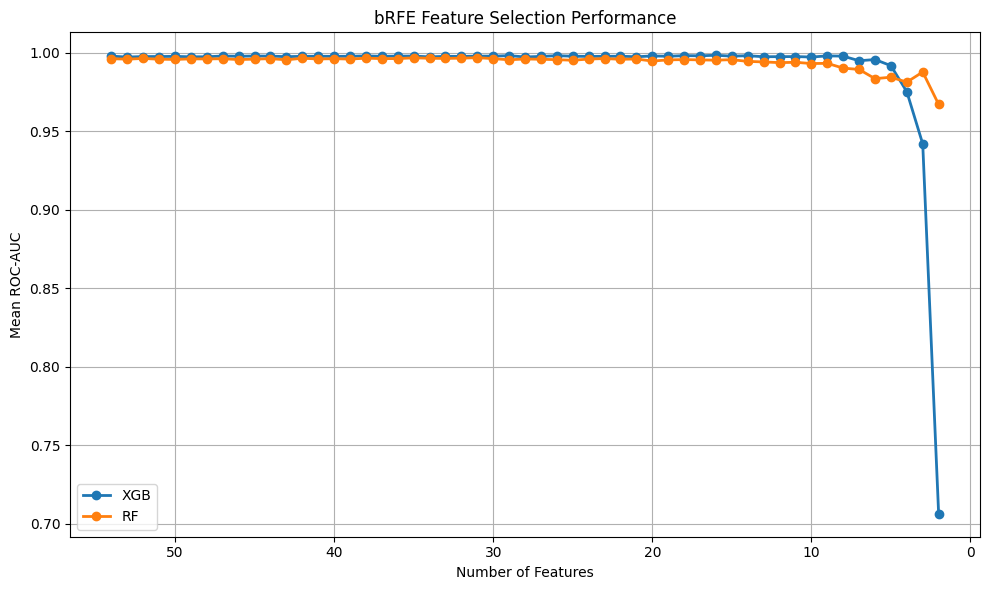

In [ ]:
import matplotlib.pyplot as plt

history = result["history"]

plt.figure(figsize=(10,6))

for learner in history["Learner"].unique():

    df = history[history["Learner"]==learner]

    plt.plot(
        df["Num_Features"],
        df["AUC"],
        marker='o',
        linewidth=2,
        label=learner
    )

plt.gca().invert_xaxis()

plt.xlabel("Number of Features")
plt.ylabel("Mean ROC-AUC")
plt.title("bRFE Feature Selection Performance")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#Plot 2 – Accuracy vs Number of Features

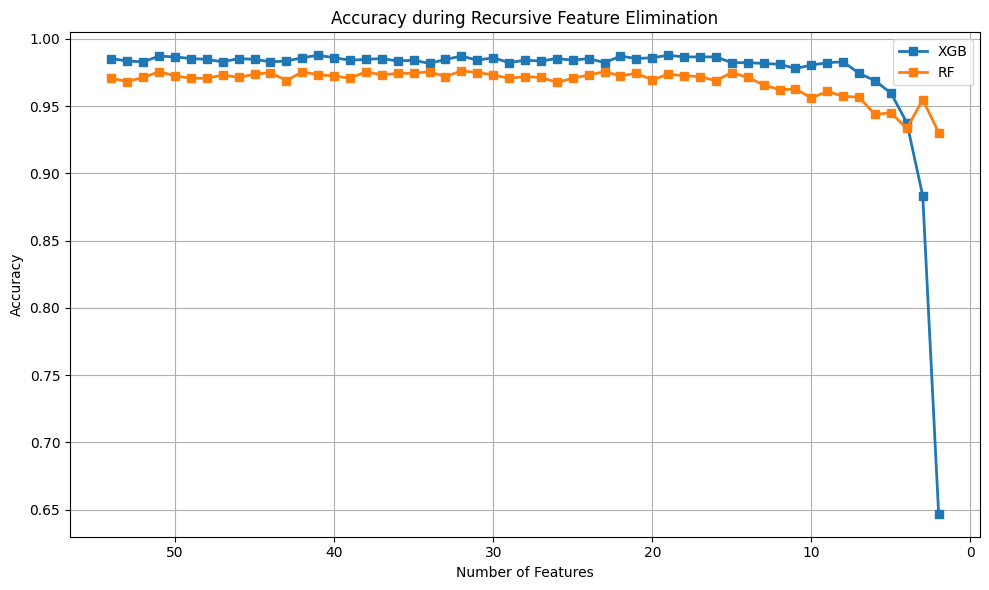

In [ ]:
plt.figure(figsize=(10,6))

for learner in history["Learner"].unique():

    df = history[history["Learner"]==learner]

    plt.plot(
        df["Num_Features"],
        df["Accuracy"],
        marker='s',
        linewidth=2,
        label=learner
    )

plt.gca().invert_xaxis()

plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Accuracy during Recursive Feature Elimination")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#Plot 3 – Combined Figure

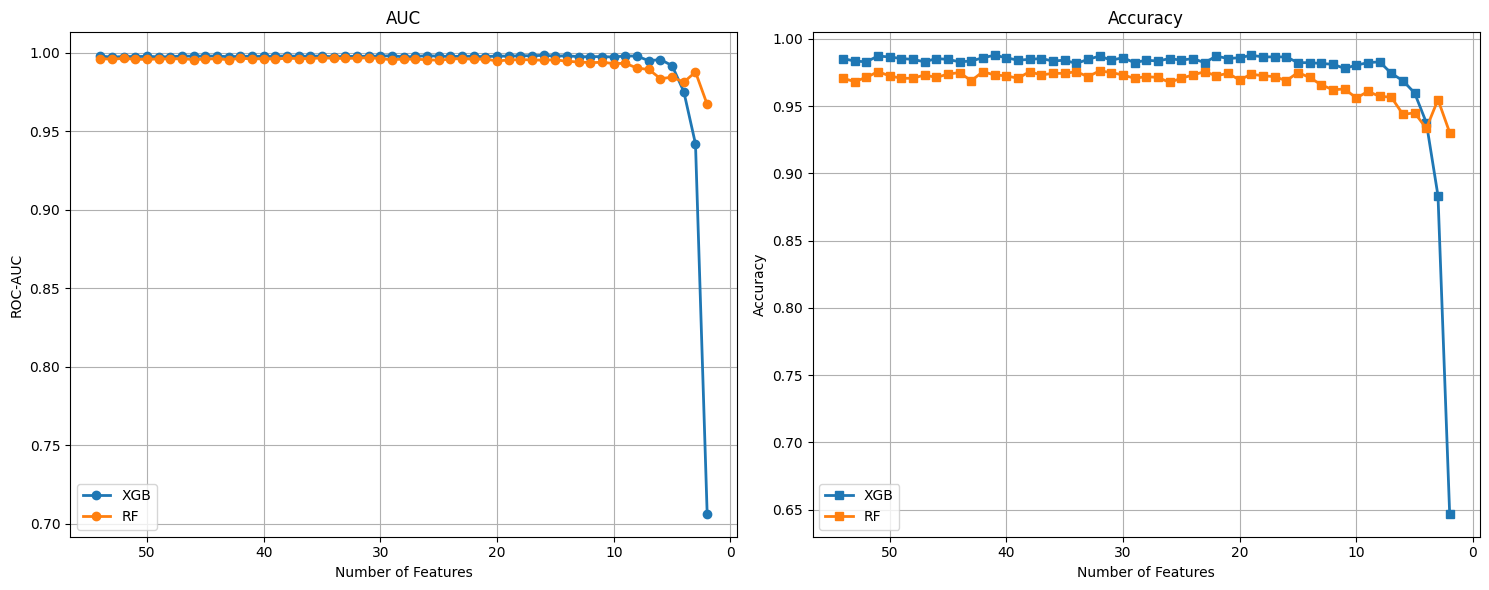

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(15,6))

for learner in history["Learner"].unique():

    df = history[history["Learner"]==learner]

    ax[0].plot(
        df["Num_Features"],
        df["AUC"],
        marker='o',
        linewidth=2,
        label=learner
    )

    ax[1].plot(
        df["Num_Features"],
        df["Accuracy"],
        marker='s',
        linewidth=2,
        label=learner
    )

ax[0].invert_xaxis()
ax[1].invert_xaxis()

ax[0].set_xlabel("Number of Features")
ax[1].set_xlabel("Number of Features")

ax[0].set_ylabel("ROC-AUC")
ax[1].set_ylabel("Accuracy")

ax[0].set_title("AUC")
ax[1].set_title("Accuracy")

ax[0].grid(True)
ax[1].grid(True)

ax[0].legend()
ax[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# Efficient SMOTE-based Oversampling Method (ESOM)
#
# Author : Saifur Rahaman
# Thesis : ClinicalEarlyCancerDF
# =============================================================================

import numpy as np
import pandas as pd

from collections import Counter
from imblearn.over_sampling import SMOTE


def ESOM(
        X_train,
        y_train,
        imbalance_threshold=5,
        random_state=42,
        verbose=True):
    """
    ===========================================================================
    Efficient SMOTE-based Oversampling Method (ESOM)

    Purpose
    -------
    Automatically detect class imbalance and apply SMOTE only when
    the imbalance exceeds a predefined threshold.

    Parameters
    ----------
    X_train : ndarray

    y_train : ndarray

    imbalance_threshold : float
        Percentage imbalance required before applying SMOTE.

    random_state : int

    verbose : bool

    Returns
    -------
    dict
    """

    if verbose:

        print("\n")
        print("=" * 75)
        print(" Efficient SMOTE-based Oversampling Method (ESOM)")
        print("=" * 75)

    # ==============================================================
    # Original Class Distribution
    # ==============================================================

    original_distribution = Counter(y_train)

    if verbose:

        print("\nOriginal Class Distribution")

        for cls in sorted(original_distribution.keys()):

            print(f"Class {cls}: {original_distribution[cls]}")

    majority_class = max(
        original_distribution,
        key=original_distribution.get
    )

    minority_class = min(
        original_distribution,
        key=original_distribution.get
    )

    majority_count = original_distribution[majority_class]
    minority_count = original_distribution[minority_class]

    imbalance_percent = (
        (majority_count - minority_count)
        / majority_count
    ) * 100

    if verbose:

        print(f"\nMajority Class : {majority_class}")
        print(f"Minority Class : {minority_class}")
        print(f"Class Imbalance: {imbalance_percent:.2f}%")

    # ==============================================================
    # Determine whether SMOTE is required
    # ==============================================================

    apply_smote = imbalance_percent > imbalance_threshold

    if not apply_smote:

        if verbose:

            print("\nDataset is sufficiently balanced.")
            print("SMOTE not required.")

        return {

            "X_train": X_train,

            "y_train": y_train,

            "applied": False,

            "threshold": imbalance_threshold,

            "imbalance": imbalance_percent,

            "original_distribution": original_distribution,

            "balanced_distribution": original_distribution,

            "generated_samples": 0

        }

    # ==============================================================
    # Adaptive k-neighbors
    # ==============================================================

    minority_size = minority_count

    if minority_size <= 2:

        k_neighbors = 1

    else:

        k_neighbors = min(
            5,
            minority_size - 1
        )

    if verbose:

        print("\nApplying Adaptive SMOTE")
        print(f"k_neighbors = {k_neighbors}")

    # ==============================================================
    # SMOTE
    # ==============================================================

    smote = SMOTE(

        sampling_strategy='auto',

        random_state=random_state,

        k_neighbors=k_neighbors

    )

    X_resampled, y_resampled = smote.fit_resample(

        X_train,

        y_train

    )

    # ==============================================================
    # Statistics
    # ==============================================================

    balanced_distribution = Counter(y_resampled)

    generated_samples = (

        len(y_resampled)

        -

        len(y_train)

    )

    if verbose:

        print("\nBalanced Class Distribution")

        for cls in sorted(balanced_distribution.keys()):

            print(f"Class {cls}: {balanced_distribution[cls]}")

        print(f"\nGenerated Samples : {generated_samples}")

        print("=" * 75)

    # ==============================================================
    # Return
    # ==============================================================

    return {

        "X_train": X_resampled,

        "y_train": y_resampled,

        "applied": True,

        "threshold": imbalance_threshold,

        "imbalance": imbalance_percent,

        "original_distribution": original_distribution,

        "balanced_distribution": balanced_distribution,

        "generated_samples": generated_samples

    }

# **Complete EOLF**

In [ ]:
# =============================================================================
# Ensemble Optimization Learning Framework (EOLF)
# =============================================================================

from copy import deepcopy

import numpy as np
import pandas as pd

from sklearn.base import clone

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


def EOLF(
        X_train,
        y_train,
        random_state=42,
        inner_cv=5,
        scoring='roc_auc',
        verbose=True):

    """
    Ensemble Optimization Learning Framework
    """

    cv = StratifiedKFold(
        n_splits=inner_cv,
        shuffle=True,
        random_state=random_state
    )

    # ==========================================================
    # Candidate Models
    # ==========================================================

    candidate_models = {

        "RF": (

            RandomForestClassifier(
                random_state=random_state,
                n_jobs=-1
            ),

            {
                "n_estimators":[100,200,300],
                "max_depth":[None,10,20],
                "min_samples_split":[2,5],
                "min_samples_leaf":[1,2]
            }

        ),

        "XGB": (

            XGBClassifier(
                eval_metric="logloss",
                random_state=random_state,
                n_jobs=-1
            ),

            {
                "n_estimators":[100,200],
                "max_depth":[3,5,7],
                "learning_rate":[0.05,0.1],
                "subsample":[0.8,1.0]
            }

        ),

        "ExtraTrees": (

            ExtraTreesClassifier(
                random_state=random_state,
                n_jobs=-1
            ),

            {
                "n_estimators":[100,200],
                "max_depth":[None,10,20]
            }

        ),

        "AdaBoost": (

            AdaBoostClassifier(
                random_state=random_state
            ),

            {
                "n_estimators":[50,100,200],
                "learning_rate":[0.5,1.0]
            }

        ),

        "GradientBoosting": (

            GradientBoostingClassifier(
                random_state=random_state
            ),

            {
                "n_estimators":[100,200],
                "learning_rate":[0.05,0.1],
                "max_depth":[3]
            }

        ),

        "LightGBM": (

            LGBMClassifier(
                random_state=random_state,
                verbose=-1
            ),

            {
                "n_estimators":[100,200],
                "learning_rate":[0.05,0.1],
                "num_leaves":[31,63]
            }

        )

    }

    results=[]

    best_auc=-np.inf
    best_acc=-np.inf
    best_name=None
    best_model=None
    best_params=None

    # ==========================================================
    # Evaluate Every Candidate
    # ==========================================================

    for name,(model,param_grid) in candidate_models.items():

        if verbose:

            print("\n"+"="*70)
            print("Evaluating :",name)

        search=GridSearchCV(

            estimator=model,

            param_grid=param_grid,

            scoring=scoring,

            cv=cv,

            n_jobs=-1,

            refit=True

        )

        search.fit(

            X_train,

            y_train

        )

        best_estimator=search.best_estimator_

        auc=np.mean(

            cross_val_score(

                best_estimator,

                X_train,

                y_train,

                cv=cv,

                scoring="roc_auc",

                n_jobs=-1

            )

        )

        acc=np.mean(

            cross_val_score(

                best_estimator,

                X_train,

                y_train,

                cv=cv,

                scoring="accuracy",

                n_jobs=-1

            )

        )

        results.append({

            "Model":name,

            "AUC":auc,

            "Accuracy":acc,

            "BestParameters":search.best_params_

        })

        if verbose:

            print("Best AUC :",round(auc,4))
            print("Best ACC :",round(acc,4))

        update=False

        if auc>best_auc:

            update=True

        elif np.isclose(auc,best_auc):

            if acc>best_acc:

                update=True

        if update:

            best_auc=auc

            best_acc=acc

            best_name=name

            best_model=deepcopy(best_estimator)

            best_params=search.best_params_

    results_df=pd.DataFrame(results)

    if verbose:

        print("\n")
        print("="*80)
        print("EOLF Completed")
        print("="*80)

        print(results_df)

        print("\nSelected Model :",best_name)
        print("Best AUC :",round(best_auc,4))
        print("Best ACC :",round(best_acc,4))

    return{

        "model_name":best_name,

        "best_model":best_model,

        "best_params":best_params,

        "auc":best_auc,

        "accuracy":best_acc,

        "results":results_df

    }

In [ ]:
# =============================================================================
# Ensemble Optimization Learning Framework (EOLF)
# =============================================================================

from copy import deepcopy

import numpy as np
import pandas as pd

from sklearn.base import clone

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


def EOLF(
        X_train,
        y_train,
        random_state=42,
        inner_cv=5,
        scoring='roc_auc',
        verbose=True):

    """
    Ensemble Optimization Learning Framework
    """

    cv = StratifiedKFold(
        n_splits=inner_cv,
        shuffle=True,
        random_state=random_state
    )

    # ==========================================================
    # Candidate Models
    # ==========================================================

    candidate_models = {

        "RF": (

            RandomForestClassifier(
                random_state=random_state,
                n_jobs=-1
            ),

            {
                "n_estimators":[100,200,300],
                "max_depth":[None,10,20],
                "min_samples_split":[2,5],
                "min_samples_leaf":[1,2]
            }

        ),

        "XGB": (

            XGBClassifier(
                eval_metric="logloss",
                random_state=random_state,
                n_jobs=-1
            ),

            {
                "n_estimators":[100,200],
                "max_depth":[3,5,7],
                "learning_rate":[0.05,0.1],
                "subsample":[0.8,1.0]
            }

        ),

        "LightGBM": (

            LGBMClassifier(
                random_state=random_state,
                verbose=-1
            ),

            {
                "n_estimators":[100,200],
                "learning_rate":[0.05,0.1],
                "num_leaves":[31,63]
            }

        )

    }

    results=[]

    best_auc=-np.inf
    best_acc=-np.inf
    best_name=None
    best_model=None
    best_params=None

    # ==========================================================
    # Evaluate Every Candidate
    # ==========================================================

    for name,(model,param_grid) in candidate_models.items():

        if verbose:

            print("\n"+"="*70)
            print("Evaluating :",name)

        search=GridSearchCV(

            estimator=model,

            param_grid=param_grid,

            scoring=scoring,

            cv=cv,

            n_jobs=-1,

            refit=True

        )

        search.fit(

            X_train,

            y_train

        )

        best_estimator=search.best_estimator_

        auc=np.mean(

            cross_val_score(

                best_estimator,

                X_train,

                y_train,

                cv=cv,

                scoring="roc_auc",

                n_jobs=-1

            )

        )

        acc=np.mean(

            cross_val_score(

                best_estimator,

                X_train,

                y_train,

                cv=cv,

                scoring="accuracy",

                n_jobs=-1

            )

        )

        results.append({

            "Model":name,

            "AUC":auc,

            "Accuracy":acc,

            "BestParameters":search.best_params_

        })

        if verbose:

            print("Best AUC :",round(auc,4))
            print("Best ACC :",round(acc,4))

        update=False

        if auc>best_auc:

            update=True

        elif np.isclose(auc,best_auc):

            if acc>best_acc:

                update=True

        if update:

            best_auc=auc

            best_acc=acc

            best_name=name

            best_model=deepcopy(best_estimator)

            best_params=search.best_params_

    results_df=pd.DataFrame(results)

    if verbose:

        print("\n")
        print("="*80)
        print("EOLF Completed")
        print("="*80)

        print(results_df)

        print("\nSelected Model :",best_name)
        print("Best AUC :",round(best_auc,4))
        print("Best ACC :",round(best_acc,4))

    return{

        "model_name":best_name,

        "best_model":best_model,

        "best_params":best_params,

        "auc":best_auc,

        "accuracy":best_acc,

        "results":results_df

    }

# **ClinicalEarlyCancerDF**

In [ ]:
# =============================================================================
# ClinicalEarlyCancerDF
# Nested Cross Validation
# =============================================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

outer_cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

results = []

fold = 1

print("="*80)
print("ClinicalEarlyCancerDF")
print("Nested Cross Validation")
print("="*80)

for train_idx, test_idx in outer_cv.split(X_processed_df, y_encoded): # Use X_processed_df and y_encoded

    print("\n")
    print("="*80)
    print(f"Outer Fold {fold}")
    print("="*80)

    ##################################################################
    # Split
    ##################################################################

    # Use .iloc to select rows by integer position and convert to numpy arrays
    X_train_current = X_processed_df.iloc[train_idx].values
    X_test_current = X_processed_df.iloc[test_idx].values # Keep this for final evaluation

    y_train_current = y_encoded[train_idx]
    y_test_current = y_encoded[test_idx]

    ##################################################################
    # bRFE
    ##################################################################

    print("\nRunning bRFE...")

    brfe_result = bRFE(

        X_train_current, # Pass the current training set

        y_train_current, # Pass the current training target

        feature_names=all_feature_names # Use all_feature_names

    )

    selected_idx = brfe_result["selected_idx"]

    # Select features from both training and test sets for this fold
    X_train_current = X_train_current[:, selected_idx]
    X_test_current = X_test_current[:, selected_idx]

    ##################################################################
    # ESOM
    ##################################################################

    print("\nRunning ESOM...")

    esom_result = ESOM(

        X_train_current,

        y_train_current,

        imbalance_threshold=5,

        random_state=42

    )

    X_train_current = esom_result["X_train"]
    y_train_current = esom_result["y_train"]

    ##################################################################
    # EOLF
    ##################################################################

    print("\nRunning EOLF...")

    eolf_result = EOLF(

        X_train_current,

        y_train_current,

        random_state=42,

        inner_cv=5

    )

    best_model = eolf_result["best_model"]

    ##################################################################
    # Final Model
    ##################################################################

    print("\nTraining Final Model...")

    best_model.fit(

        X_train_current,

        y_train_current

    )

    ##################################################################
    # Test
    ##################################################################

    y_pred = best_model.predict(X_test_current)

    y_prob = best_model.predict_proba(X_test_current)[:,1]

    ##################################################################
    # Metrics
    ##################################################################

    acc = accuracy_score(y_test_current, y_pred)

    auc = roc_auc_score(y_test_current, y_prob)

    precision = precision_score(y_test_current, y_pred)

    recall = recall_score(y_test_current, y_pred)

    f1 = f1_score(y_test_current, y_pred)

    pr_auc = average_precision_score(y_test_current, y_prob)

    tn, fp, fn, tp = confusion_matrix(
        y_test_current,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    ##################################################################
    # Store
    ##################################################################

    results.append({

        "Fold":fold,

        "Model":eolf_result["model_name"],

        "Features":len(selected_idx),

        "Accuracy":acc,

        "AUC":auc,

        "Precision":precision,

        "Recall":recall,

        "Specificity":specificity,

        "F1":f1,

        "PR_AUC":pr_auc

    })

    ##################################################################
    # Print
    ##################################################################

    print("\nFold Results")

    print(f"Model        : {eolf_result['model_name']}")
    print(f"Features     : {len(selected_idx)}")
    print(f"Accuracy     : {acc:.4f}")
    print(f"AUC          : {auc:.4f}")
    print(f"Precision    : {precision:.4f}")
    print(f"Recall       : {recall:.4f}")
    print(f"Specificity  : {specificity:.4f}")
    print(f"F1-score     : {f1:.4f}")
    print(f"PR-AUC       : {pr_auc:.4f}")

    fold += 1

##########################################################################
# Overall Results
##########################################################################

results_df = pd.DataFrame(results)

print("\n")
print("="*90)
print("Overall Performance")
print("="*90)

print(results_df)

print("\nAverage Performance")

print(results_df.mean(numeric_only=True))

print("\nStandard Deviation")

print(results_df.std(numeric_only=True))


ClinicalEarlyCancerDF
Nested Cross Validation


Outer Fold 1

Running bRFE...
Best Recursive Feature Elimination (bRFE)

Evaluating learner: XGB
Remaining Features: 53 | AUC=0.9978 | ACC=0.9872
Remaining Features: 52 | AUC=0.9977 | ACC=0.9829
Remaining Features: 51 | AUC=0.9979 | ACC=0.9872
Remaining Features: 50 | AUC=0.9980 | ACC=0.9853
Remaining Features: 49 | AUC=0.9981 | ACC=0.9872
Remaining Features: 48 | AUC=0.9978 | ACC=0.9841
Remaining Features: 47 | AUC=0.9978 | ACC=0.9884
Remaining Features: 46 | AUC=0.9980 | ACC=0.9841
Remaining Features: 45 | AUC=0.9979 | ACC=0.9810
Remaining Features: 44 | AUC=0.9982 | ACC=0.9847
Remaining Features: 43 | AUC=0.9979 | ACC=0.9866
Remaining Features: 42 | AUC=0.9981 | ACC=0.9847
Remaining Features: 41 | AUC=0.9976 | ACC=0.9866
Remaining Features: 40 | AUC=0.9982 | ACC=0.9878
Remaining Features: 39 | AUC=0.9978 | ACC=0.9841
Remaining Features: 38 | AUC=0.9979 | ACC=0.9872
Remaining Features: 37 | AUC=0.9976 | ACC=0.9853
Remaining Features: 36

# **Section 13 — Bayesian Objective**

In [ ]:
def rf_objective(n_estimators, max_depth, min_samples_split, min_samples_leaf):

    # Section 14 — Bayesian Search
  optimizer = BayesianOptimization(f=rf_objective,

  pbounds={

        "n_estimators": (100,300),

        "max_depth": (5,30),

        "min_samples_split": (2,20),

        "min_samples_leaf": (1,10)

  },

  random_state=RANDOM_STATE,

  verbose=0)

  optimizer.maximize(

    init_points=5,

    n_iter=N_BAYES_ITER

  )

  best_params = optimizer.max["params"]

  best_params["n_estimators"] = int(best_params["n_estimators"])

  best_params["max_depth"] = int(best_params["max_depth"])

  best_params["min_samples_split"] = int(best_params["min_samples_split"])

  best_params["min_samples_leaf"] = int(best_params["min_samples_leaf"])

  print(best_params)

{'n_estimators': 277, 'max_depth': 18, 'min_samples_split': 5, 'min_samples_leaf': 1}


# Data imputation using LightGBM

In [ ]:
import pandas as pd
import numpy as np

# File path from the user's prompt
file_path = "/content/drive/MyDrive/ClinicalEarlyCancerDF/Data/CancerSEEK_Dataset.csv"


try:
    # Load the dataset with 'latin1' encoding
    df = pd.read_csv(file_path, encoding='latin1')
    print(f"Dataset loaded successfully from: {file_path}")
    print(f"Original shape: {df.shape}")
    print("\nFirst 5 rows of the dataset:")
    print(df.head())
    print("\nDataset Info (before imputation):")
    df.info()

    # Check for missing values
    total_missing_before = df.isnull().sum().sum()

    if total_missing_before > 0:
        print(f"\nMissing values found in the dataset: {total_missing_before}")
        print("Attempting to apply LightGBM imputation to numerical columns...")

        # Separate numerical and non-numerical columns
        numerical_cols = df.select_dtypes(include=np.number).columns
        non_numerical_cols_with_nan = df.select_dtypes(exclude=np.number).columns[df.select_dtypes(exclude=np.number).isnull().any()]

        if len(numerical_cols) > 0 and df[numerical_cols].isnull().any().any():
            print(f"Imputing {len(numerical_cols)} numerical columns with missing values.")
            # Enable IterativeImputer (experimental)
            from sklearn.experimental import enable_iterative_imputer
            from sklearn.impute import IterativeImputer
            from lightgbm import LGBMRegressor

            # Initialize IterativeImputer with LGBMRegressor
            # verbose=0 to suppress iteration messages during fit_transform
            imputer = IterativeImputer(estimator=LGBMRegressor(random_state=42), max_iter=10, random_state=42, verbose=0)

            # Create a copy for imputation to avoid SettingWithCopyWarning if df is a slice
            df_numerical_part = df[numerical_cols].copy()

            # Apply imputation to numerical columns
            df_numerical_imputed_array = imputer.fit_transform(df_numerical_part)
            df_numerical_imputed = pd.DataFrame(df_numerical_imputed_array, columns=numerical_cols, index=df.index)

            # Update the original DataFrame with the imputed numerical columns
            for col in numerical_cols:
                df[col] = df_numerical_imputed[col]

            print("LightGBM imputation applied successfully to numerical columns.")

        else:
            print("No numerical columns with missing values found for LightGBM imputation.")

        # Check if any non-numerical columns still have missing values
        total_missing_after_numerical_imputation = df.isnull().sum().sum()
        if total_missing_after_numerical_imputation > 0:
            print(f"\nAfter numerical imputation, {total_missing_after_numerical_imputation} missing values still remain.")
            if len(non_numerical_cols_with_nan) > 0:
                print(f"Missing values are present in non-numerical columns: {list(non_numerical_cols_with_nan)}")
                print("LightGBM IterativeImputer is primarily designed for numerical data. You might consider using mode imputation, a specific categorical imputer, or one-hot encoding followed by numerical imputation for these columns.")
        else:
            print("\nAll missing values have been successfully imputed.")


    else:
        print("\nNo missing values found in the dataset. No imputation needed.")

    print("\nDataset Info after processing:")
    df.info()
    print("\nFirst 5 rows of the processed dataset:")
    print(df.head())

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")
except ImportError as ie:
    print(f"Import Error: {ie}. Make sure you have 'scikit-learn' and 'lightgbm' installed.")
    print("You might need to run: !pip install scikit-learn lightgbm")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Dataset loaded successfully from: /content/drive/MyDrive/ClinicalEarlyCancerDF/Data/CancerSEEK_Dataset.csv
Original shape: (1818, 49)

First 5 rows of the dataset:
   Plasma volume (mL)  Plasma D0 concentration (ng/mL)  ½ score  \
0                 5.0                             6.08   2.9628   
1                 4.0                            46.01   2.4454   
2                 4.5                             6.94   1.2158   
3                 7.5                             7.15   1.6408   
4                 5.0                             9.81   1.3258   

   Mutant allele frequency (%)   Mutant fragments/mL plasma  AFP (pg/ml)  \
0                         0.27                       5.0968     1583.450   
1                         0.02                       3.2059      715.308   
2                         0.06                       1.3565     4365.530   
3                         0.16                       3.6332      715.308   
4                         0.08                       

# 10 fold stratified CV:

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
import sys

# Install bayesian-optimization if not already installed
try:
    from bayes_opt import BayesianOptimization
except ImportError:
    print("Installing bayesian-optimization library...")
    !pip install bayesian-optimization
    from bayes_opt import BayesianOptimization

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- 1. Data Preparation ---
print("--- Data Preparation ---")

# Assuming 'df' is already loaded from the previous cell and potentially imputed for numerical columns.
# Let's re-verify the state of 'df' and handle any remaining issues.

# Check for missing values in non-numerical columns and display full info
print("\nDataFrame Info (before specific preprocessing steps):")
df.info()

print("\nMissing values before further processing (all columns):")
missing_values_before = df.isnull().sum()
print(missing_values_before[missing_values_before > 0])

# Impute missing values in non-numerical columns with their mode
for col in df.select_dtypes(exclude=np.number).columns:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Imputed missing values in categorical column '{col}' with mode: {mode_val}")

print("\nMissing values after mode imputation for non-numerical columns:")
missing_values_after_mode = df.isnull().sum()
if missing_values_after_mode[missing_values_after_mode > 0].empty:
    print("No missing values remaining in the DataFrame after mode imputation for categorical columns.")
else:
    print(missing_values_after_mode[missing_values_after_mode > 0])
    print("Warning: Some numerical missing values might still exist if not handled by the previous step.")


# Separate features (X) and target (y)
if 'class' not in df.columns:
    raise ValueError("Target column 'class' not found in the DataFrame.")

X = df.drop('class', axis=1)
X = X.drop('Tumor type', axis=1)
y = df['class']

# Encode the target variable 'y'
print(f"\nUnique values in target variable 'class': {y.unique()}")
print(f"Value counts for target variable 'class':\n{y.value_counts()}")
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Target variable encoded: {list(le.classes_)} -> {list(le.transform(le.classes_))}")

# Identify categorical features for One-Hot Encoding
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=np.number).columns

# Create a preprocessor for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough' # Keep numerical features as they are
)

# Apply preprocessing to X
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
try:
    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    passthrough_feature_names = numerical_features.tolist()
    all_feature_names = ohe_feature_names.tolist() + passthrough_feature_names
    X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names, index=X.index)
except AttributeError:
    print("Warning: get_feature_names_out() not available. Column names for X_processed_df might be generic.")
    X_processed_df = pd.DataFrame(X_processed, index=X.index) # Fallback if get_feature_names_out fails


print(f"\nOriginal features shape: {X.shape}")
print(f"Processed features shape after One-Hot Encoding: {X_processed_df.shape}")
print(f"Number of target samples: {len(y_encoded)}")


# --- 2. Define Metrics and Storage ---
accuracy_scores = []
auc_scores = []
selected_features_per_fold = []

# --- 3. Outer Stratified K-Fold Loop ---
n_splits_outer = 10
skf_outer = StratifiedKFold(n_splits=n_splits_outer, shuffle=True, random_state=42)

print(f"\n--- Starting {n_splits_outer}-fold Stratified Cross-Validation ---")

for fold, (train_index_outer, test_index_outer) in enumerate(skf_outer.split(X_processed_df, y_encoded)):
    print(f"\n--- Outer Fold {fold + 1}/{n_splits_outer} ---")

    X_train_outer, X_test_outer = X_processed_df.iloc[train_index_outer], X_processed_df.iloc[test_index_outer]
    y_train_outer, y_test_outer = y_encoded[train_index_outer], y_encoded[test_index_outer]

    # --- 4. Inner Feature Selection (RFECV with RandomForestClassifier) ---
    print("Performing RFE for feature selection on outer training data...")
    rf_rfe = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # Use all available cores
    # Using RFECV to automatically select the optimal number of features
    # min_features_to_select set to 5 to ensure at least some features are kept.
    # cv=3 for inner CV for RFE. scoring='roc_auc' is appropriate for classification.
    rfe_selector = RFECV(estimator=rf_rfe, step=1, cv=StratifiedKFold(3, shuffle=True, random_state=42), scoring='roc_auc', n_jobs=-1, min_features_to_select=5)
    rfe_selector.fit(X_train_outer, y_train_outer)

    X_train_selected = X_train_outer.loc[:, rfe_selector.get_support()]
    X_test_selected = X_test_outer.loc[:, rfe_selector.get_support()]

    selected_features = X_processed_df.columns[rfe_selector.get_support()].tolist()
    selected_features_per_fold.append(selected_features)

    print(f"Number of features selected in fold {fold + 1}: {len(selected_features)}")
    # print(f"Selected features for fold {fold + 1}: {selected_features}") # Can be very verbose

    # If no features selected, or too few, handle gracefully
    if X_train_selected.shape[1] == 0:
        print(f"Warning: No features selected by RFE in fold {fold+1}. Skipping Bayesian Optimization and model training for this fold.")
        accuracy_scores.append(np.nan)
        auc_scores.append(np.nan)
        continue

    # --- 5. Inner Hyperparameter Tuning (Bayesian Optimization for RandomForest) ---
    print("Performing Bayesian Optimization for RandomForest hyperparameters...")

    # Objective function for Bayesian Optimization
    def rf_objective(n_estimators, max_depth, min_samples_split, min_samples_leaf):
        # Cast parameters to appropriate types
        n_estimators = int(n_estimators)
        max_depth = int(max_depth) if int(max_depth) > 0 else 1 # Ensure max_depth is at least 1
        min_samples_split = int(min_samples_split)
        min_samples_leaf = int(min_samples_leaf)

        # Ensure min_samples_split and min_samples_leaf are valid given the data size
        min_samples_split = max(2, min_samples_split)
        min_samples_leaf = max(1, min_samples_leaf)

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42,
            n_jobs=-1 # Use all available cores
        )

        # Inner cross-validation for hyperparameter tuning
        # Use 3-fold inner CV, consistent with RFE.
        skf_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        inner_cv_auc_scores = []
        for train_index_inner, val_index_inner in skf_inner.split(X_train_selected, y_train_outer):
            X_train_inner, X_val_inner = X_train_selected.iloc[train_index_inner], X_train_selected.iloc[val_index_inner]
            y_train_inner, y_val_inner = y_train_outer[train_index_inner], y_train_outer[val_index_inner]

            if len(np.unique(y_train_inner)) < 2 or len(np.unique(y_val_inner)) < 2:
                # Handle cases where a fold might not have both classes, especially with small dataset or highly imbalanced classes
                # This could cause roc_auc_score to fail. Return a low value.
                inner_cv_auc_scores.append(0.0)
                continue

            model.fit(X_train_inner, y_train_inner)
            y_pred_proba_inner = model.predict_proba(X_val_inner)[:, 1]
            inner_cv_auc_scores.append(roc_auc_score(y_val_inner, y_pred_proba_inner))

        # If no valid scores were collected, return 0.0
        return np.mean(inner_cv_auc_scores) if inner_cv_auc_scores else 0.0


    # Parameter bounds for Bayesian Optimization
    pbounds = {
        'n_estimators': (50, 250), # Number of trees in the forest
        'max_depth': (5, 30),      # Maximum depth of the tree
        'min_samples_split': (2, 20), # Minimum number of samples required to split an internal node
        'min_samples_leaf': (1, 10) # Minimum number of samples required to be at a leaf node
    }

    optimizer = BayesianOptimization(
        f=rf_objective,
        pbounds=pbounds,
        random_state=42,
        verbose=0 # Suppress Bayesian Optimization progress messages
    )

    optimizer.maximize(
        init_points=5, # Number of random exploration steps
        n_iter=10     # Number of optimization steps
    )

    best_params = optimizer.max['params']
    # Cast to int as BO provides floats
    best_params['n_estimators'] = int(best_params['n_estimators'])
    best_params['max_depth'] = int(best_params['max_depth'])
    best_params['min_samples_split'] = int(best_params['min_samples_split'])
    best_params['min_samples_leaf'] = int(best_params['min_samples_leaf'])

    # Re-apply bounds to int-casted values to ensure they are valid for the model
    best_params['max_depth'] = max(1, best_params['max_depth'])
    best_params['min_samples_split'] = max(2, best_params['min_samples_split'])
    best_params['min_samples_leaf'] = max(1, best_params['min_samples_leaf'])


    print(f"Best hyperparameters found for fold {fold + 1}: {best_params}")

    # --- 6. Model Training and Evaluation on Outer Fold ---
    print("Training final RandomForest model and evaluating on outer test set...")
    final_rf_model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
    final_rf_model.fit(X_train_selected, y_train_outer)

    y_pred_proba = final_rf_model.predict_proba(X_test_selected)[:, 1]
    y_pred_class = final_rf_model.predict(X_test_selected)

    fold_auc = roc_auc_score(y_test_outer, y_pred_proba)
    fold_accuracy = accuracy_score(y_test_outer, y_pred_class)

    accuracy_scores.append(fold_accuracy)
    auc_scores.append(fold_auc)

    print(f"Fold {fold + 1} - Accuracy: {fold_accuracy:.4f}, AUC: {fold_auc:.4f}")

# --- 7. Final Results ---
print("\n--- Cross-Validation Summary ---")
# Filter out potential NaNs if a fold was skipped
accuracy_scores_clean = [score for score in accuracy_scores if not np.isnan(score)]
auc_scores_clean = [score for score in auc_scores if not np.isnan(score)]

if accuracy_scores_clean and auc_scores_clean:
    print(f"Mean Accuracy across {len(accuracy_scores_clean)} folds: {np.mean(accuracy_scores_clean):.4f} (+/- {np.std(accuracy_scores_clean):.4f})")
    print(f"Mean AUC across {len(auc_scores_clean)} folds: {np.mean(auc_scores_clean):.4f} (+/- {np.std(auc_scores_clean):.4f})")
else:
    print("No valid scores were recorded. This might indicate issues during feature selection or model training in all folds.")

print("\nNumber of selected features per fold:")
for i, features in enumerate(selected_features_per_fold):
    print(f"Fold {i+1}: {len(features)} features")

--- Data Preparation ---

DataFrame Info (before specific preprocessing steps):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1818 entries, 0 to 1817
Data columns (total 49 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Plasma volume (mL)               1818 non-null   float64
 1   Plasma D0 concentration (ng/mL)  1818 non-null   float64
 2   ½ score                          1818 non-null   float64
 3   Mutant allele frequency (%)      1818 non-null   float64
 4    Mutant fragments/mL plasma      1818 non-null   float64
 5   AFP (pg/ml)                      1818 non-null   float64
 6   Angiopoietin-2 (pg/ml)           1818 non-null   float64
 7   AXL (pg/ml)                      1818 non-null   float64
 8   CA-125 (U/ml)                    1818 non-null   float64
 9   CA 15-3 (U/ml)                   1818 non-null   float64
 10  CA19-9 (U/ml)                    1818 non-null   float64
 11  CD